In [2]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
class Net(nn.Module):
    def __init__(self, layers=(1, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers)-2):
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*net)
    def forward(self, x):
        return self.net(x)

Consider simple ODE:
$$
\begin{cases}
u'' = 2 \\
u(0) = \frac{1}{16} \\
u(1) = \frac{9}{16}
\end{cases}
$$
The solution of the system is $u(x) = (x - \frac{1}{4})^2$

In [4]:
# --- Collocation points ---
N_f = 50
x_f = torch.rand(N_f, 1, requires_grad=True)

# --- Boundary points --
x_bc = torch.cat([torch.zeros(10, 1), torch.ones(10, 1)], dim=0)
u_bc = torch.cat([torch.full((10, 1), 1.0/16.0), torch.full((10, 1), 9.0/16.0)], dim=0)

In [8]:
net = Net((1, 20, 40, 20, 1))

optimizer = optim.Adam(net.parameters(), lr=1e-3)

for epoch in range(6001):
    optimizer.zero_grad()

    # ODE residual
    u_f = net(x_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]

    loss_ode = torch.mean((u_xx - 2) ** 2)

    # Boundary loss
    u_bc_pred = net(x_bc)
    loss_bc = torch.mean((u_bc_pred - u_bc) ** 2)

    loss = loss_ode + loss_bc
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 4.324586
Epoch 1000, Loss: 0.000138
Epoch 2000, Loss: 0.000061
Epoch 3000, Loss: 0.000020
Epoch 4000, Loss: 0.000004
Epoch 5000, Loss: 0.000002
Epoch 6000, Loss: 0.000001


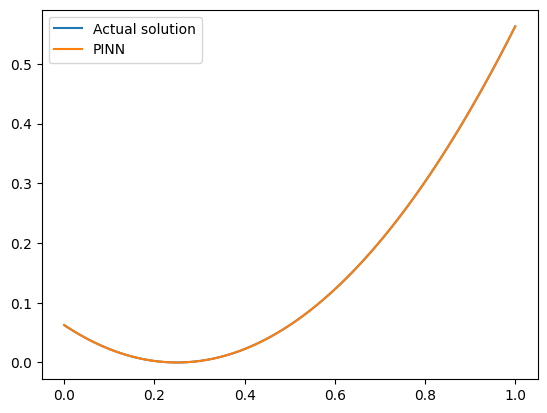

In [9]:
x_test = torch.linspace(0, 1, 100).reshape(-1, 1)

with torch.no_grad():
    u_pred = net(x_test)
    u_exact = torch.pow(x_test - 1.0/4.0, 2)

plt.plot(x_test, u_exact, label="Actual solution")
plt.plot(x_test, u_pred, label="PINN")
plt.legend()
plt.show()

In [10]:
l2_error = torch.norm(u_pred - u_exact)
print(f"L2 error: {l2_error.item()}")
l2_relative_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
print(f"Relative L2 error: {l2_relative_error.item()}")
mse = torch.mean((u_pred - u_exact)**2)
print(f"MSE: {mse.item()}")

L2 error: 0.00012354082718957216
Relative L2 error: 5.592661182163283e-05
MSE: 1.5262337227373024e-10
